In [2]:
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64

--2026-07-29 18:03:53--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.7.3/cloudflared-linux-amd64 [following]
--2026-07-29 18:03:53--  https://github.com/cloudflare/cloudflared/releases/download/2026.7.3/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/3812f7fa-ce13-4147-a9fb-197be83d49fa?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-07-29T18%3A50%3A54Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-07-29T1


# Development Server Tunnel

In [3]:
import subprocess
import re
import threading
import uvicorn
import time
import logging.config

class Tunnel:
  def __init__(self, log_file_path):
    self.process = None
    self.tunnel_url = None
    self.tunnel_thread = None
    self.log_thread = None
    self.url_found = threading.Event()   # NEW
    self.log_file_path = log_file_path
    self.log_file = None
  def start_tunnel(self, timeout=15):
    if(self.process is not None and self.process.poll() is None):
      print("Tunnel already running.")
      print("URL:", self.tunnel_url)
      return

    self.url_found.clear()               # NEW
    self.process = subprocess.Popen(
      ['./cloudflared-linux-amd64', 'tunnel', '--url', 'http://localhost:8000'],
      stdout=subprocess.PIPE,
      stderr=subprocess.PIPE,
      text=True,
      bufsize=1
    )
    print("PID:", self.process.pid)

    if(self.tunnel_thread is None or not self.tunnel_thread.is_alive()):
      self.tunnel_thread = threading.Thread(target=self.get_url, daemon=True)
      #self.log_thread = threading.Thread(target=self.log_requests, daemon=True)
      self.tunnel_thread.start()
      #self.log_thread.start()

    # Block the main thread (i.e. the cell) until the URL is captured
    if self.url_found.wait(timeout):
        print(f"Tunnel Started! URL: {self.tunnel_url}/docs")
    else:
        print("Timed out waiting for tunnel URL.")


  def log_requests(self):
    self.log_file = open(self.log_file_path, "a")
    while True:
      line = self.process.stderr.readline()
      self.log_file.write(line)
      self.log_file.flush()
      if self.process.poll() is not None:
        self.log_file.close()
        break

  def get_url(self):
    self.log_file = open(self.log_file_path, "w")
    #start_time = time.time()
    while True:
        line = self.process.stderr.readline()
        self.log_file.write(line)
        self.log_file.flush()
        m = re.search(r"https://[-a-zA-Z0-9]+\.trycloudflare\.com", line)
        if m:
            self.tunnel_url = m.group()
            self.url_found.set()
             # NEW — signals start_tunnel() to stop waiting
        if self.process.poll() is not None:
            self.log_file.close()
            break

  def terminate_tunnel(self):
    if self.process is None:
      print("Tunnel not running.")
      return
    print("Stopping tunnel...")
    self.process.terminate()
    try:
      self.process.wait(timeout=5)
    except subprocess.TimeoutExpired:
      self.process.kill()
    self.process=None
    self.tunnel_url=None
    self.tunnel_thread=None
    print("Tunnel Terminated!")



## BACKEND SERVER CLASS
class BackendServer:
  def __init__(self):
    self.server=None
    self.server_thread=None
    self.LOGGING_CONFIG = {
    "version": 1,
    "disable_existing_loggers": False,
    "formatters": {
        "default": {"format": "%(asctime)s - %(levelname)s - %(name)s - %(message)s"},
    },
    "handlers": {
        "file": {
            "class": "logging.FileHandler",
            "filename": "uvicorn.log",
            "formatter": "default",
        },
    },
    "loggers": {
        "uvicorn": {"handlers": ["file"], "level": "INFO"},
        "uvicorn.error": {"handlers": ["file"], "level": "INFO"},
        "uvicorn.access": {"handlers": ["file"], "level": "INFO"},
    },
  }
  def start_server(self, app):
    if(self.server_thread is not None and self.server_thread.is_alive()):
      print("Server already running.")
      return

    config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_config=self.LOGGING_CONFIG)
    self.server = uvicorn.Server(config)
    self.server_thread = threading.Thread(target=self.server.run, daemon=True)
    self.server_thread.start()
    print("Server started!")


  def terminate_server(self):
    if(self.server is not None):
      self.server.should_exit = True
      self.server_thread.join(timeout=5)
      self.server = None
      self.server_thread = None
      print("Server Terminated!")




In [4]:
backend = BackendServer()
tunnel = Tunnel("/content/log.txt")

#**Initialize Clip Model**

In [5]:
from PIL import Image
import torch
import requests
from transformers import CLIPProcessor, CLIPModel

from google.colab import drive
drive.mount("/content/drive")
CACHE_DIR = "/content/drive/MyDrive/CLIP_project_cache"
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32", cache_dir=CACHE_DIR)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32", cache_dir=CACHE_DIR)


torch.set_printoptions(sci_mode=False)

Mounted at /content/drive


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [ ]:
if torch.cuda.is_available():
  model.to("cuda")

# Backend Server
This will be piped through the tunnel created above

In [6]:
import threading
import uvicorn
from fastapi import FastAPI, UploadFile, File, Form
from pydantic import BaseModel
from PIL import Image
import matplotlib.pyplot as plt
from io import BytesIO
import numpy as np
from typing import List
import base64
import asyncio
import torch.nn.functional as F

In [7]:

app = FastAPI()

@app.get("/")
def home():
    return {"hello": "World"}


#, labels: List[str] = Form(...)
async def checkFiles(pics: List[UploadFile] = File(...)):
  ALLOWED_CONTENT_TYPE = ['image/jpg', 'image/jpeg', 'image/png', 'image/webp']
  ALLOWED_EXT = ['png', 'jpg', 'jpeg', 'webp']
  incorrect_files = []
  processed_images = []
  image_content = []
  for f in pics:
    if f.content_type not in ALLOWED_CONTENT_TYPE:
      incorrect_files.append(f.filename)
      continue
    ext = f.filename.split('.')[-1].lower() if '.' in f.filename else ''
    if ext not in ALLOWED_EXT:
      incorrect_files.append(f.filename)
      continue

    if f.size > 3*1024*1024:
      continue

    processed_images.append(f.filename)
    image_content.append(Image.open(BytesIO(await f.read())))

  return {
      "Incorrect Files": incorrect_files,
      "Processed Images": processed_images,
      "Image Content": image_content
  }
@app.post("/image_embedding")
async def image_embedding(pics: List[UploadFile] = File(...)):

  try:
    st = time.perf_counter()
    acceptedFiles = await checkFiles(pics)
    incorrect_files = acceptedFiles["Incorrect Files"]
    processed_images = acceptedFiles["Processed Images"]
    image_content = acceptedFiles["Image Content"]

    inputs = processor(images=image_content, return_tensors="pt", padding=True)
    if torch.cuda.is_available():
      inputs = {k: v.to("cuda") for k, v in inputs.items()}

    with torch.no_grad():
      out = model.get_image_features(**inputs)

    embed = {}
    t = True
    output = out.pooler_output
    for id, p in enumerate(processed_images):
      embed[p] = output[id].squeeze(0).cpu().tolist()
    ft = time.perf_counter()
    return {"Image_embedding": embed,
            "Incorrect Files": incorrect_files,
            "Compute Time": ft-st}
  except Exception as e:
    import traceback
    return {
        "Error": str(e),
        "Traceback": traceback.format_exc()
    }

@app.post("/text_embedding")
async def text_embedding(text: List[str] = Form(...)):
  try:
    st = time.perf_counter()
    inputs = processor(text=text, return_tensors="pt", padding=True)
    if torch.cuda.is_available():
      inputs = {k: v.to("cuda") for k, v in inputs.items()}
    with torch.no_grad():
      out = model.get_text_features(**inputs)

    embed = {}
    t = True
    output = out.pooler_output
    for id, p in enumerate(text):
      embed[p] = output[id].squeeze(0).cpu().tolist()
    ft = time.perf_counter()
    return {"Text_embedding": embed,
            "Compute Time": ft-st}

  except Exception as e:
    import traceback
    return {
        "Error": str(e),
        "Traceback": traceback.format_exc()
    }

@app.post("/similarity")
def similarity(text_embed: dict, image_embed: dict) -> dict:
  try:
    # 1. Extract IDs and stack tensors into 2D matrices: shape [N, D] and [M, D]
    text_ids = list(text_embed.keys())
    image_ids = list(image_embed.keys())

    text_mat = torch.tensor(list(text_embed.values()), dtype=torch.float32)
    image_mat = torch.tensor(list(image_embed.values()), dtype=torch.float32)
    #text_mat = torch.stack(text_tensors)   # Shape: (N_text, dim)
    #image_mat = torch.stack(image_tensors) # Shape: (N_img, dim)
    # 2. L2 normalize along the vector dimension
    text_norm = F.normalize(text_mat, p=2, dim=1)
    image_norm = F.normalize(image_mat, p=2, dim=1)

    # 3. Pairwise Cosine Similarity Matrix: [N_img, dim] @ [dim, N_text] -> [N_img, N_text]
    sim_matrix = image_norm @ text_norm.T

    return {
        "image_ids": list(image_ids),
        "text_ids": list(text_ids),
        "similarity_matrix": sim_matrix.tolist()  # PyTorch Tensor of shape (M_images, N_texts)
    }

  except Exception as e:
    import traceback
    return {
        "Error": str(e),
        "Traceback": traceback.format_exc()
    }


@app.post("/image")
async def image(pics: List[UploadFile] = File(...), labels: List[str] = Form(...)):
  acceptedFiles = await checkFiles(pics)
  incorrect_files = acceptedFiles["Incorrect Files"]
  processed_images = acceptedFiles["Processed Images"]
  image_content = acceptedFiles["Image Content"]

  #labels=["Lion", "Dog"]
  inputs = processor(text=labels, images=image_content, return_tensors="pt", padding=True)
  if torch.cuda.is_available():
    inputs = {k: v.to("cuda") for k, v in inputs.items()}
  out = model(**inputs)
  logits_per_image = out.logits_per_image.cpu()
  prob = logits_per_image.softmax(dim=1)
  associated_labels = {}
  for id, t in enumerate(prob):
    associated_labels.setdefault(labels[t.argmax()], []).append(processed_images[id])
  return {"Result": associated_labels,
          "Incorrect Files": incorrect_files }






In [ ]:
import time
time.perf

#**Start the Server**


In [8]:
#Starting the server
backend.start_server(app)
tunnel.start_tunnel()

Server started!
PID: 1933


INFO:uvicorn.error:Started server process [1173]
INFO:uvicorn.error:Waiting for application startup.
INFO:uvicorn.error:Application startup complete.
INFO:uvicorn.error:Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


Tunnel Started! URL: https://vacuum-eligibility-pretty-trade.trycloudflare.com/docs


# **Close the Server**

In [ ]:
tunnel.terminate_tunnel()
backend.terminate_server()

INFO:uvicorn.error:Shutting down
INFO:uvicorn.error:Waiting for application shutdown.
INFO:uvicorn.error:Application shutdown complete.
INFO:uvicorn.error:Finished server process [5147]


Server Terminated!


# **TESTING**

# **NOT SO IMPORTANT THINGS**

In [ ]:
from io import BytesIO

def load_image_from_url(url):
  try:
    response = requests.get(url)
    response.raise_for_status()

    img = Image.open(BytesIO(response.content))
    return img

  except requests.exceptions.RequestException as e:
    print(f'Error loading image: {e}')
    return None







In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def display_images(images):
  num_images = len(images)
  fig, axes = plt.subplots(1, num_images, figsize=(15,5))
  for id, img in enumerate(images):
    if img.mode == 'L':
      axes[id].imshow(img, cmap='gray')
    else:
      axes[id].imshow(img)
    axes[id].set_title(f'Image {id+1}')

  plt.show()



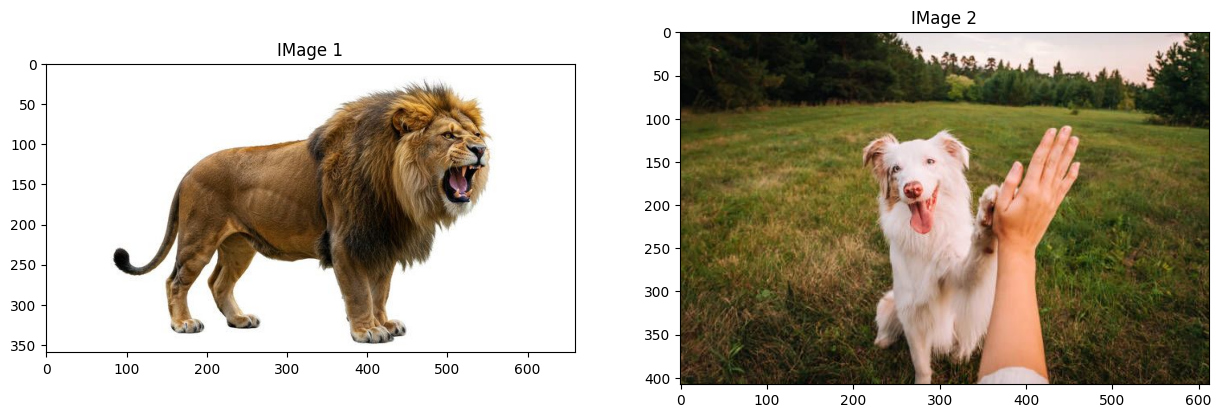

In [ ]:
u1 = "https://imgs.search.brave.com/lDOyeExoxqXDrI3w3aZLLBOsRwdfa9Oobxl1LSwZpjA/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly90NC5m/dGNkbi5uZXQvanBn/LzEyLzgwLzkzLzkz/LzM2MF9GXzEyODA5/MzkzMThfZ0x2U2c4/ZTM2eUZ1RkNZb1k2/elYzekJRTlRmNVJZ/MHQuanBn"
u2 = "https://imgs.search.brave.com/zIFyFvRW3I7LcNIeCYHKyZwV_ru1TZzTyikX-p9AWdA/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly9tZWRp/YS5pc3RvY2twaG90/by5jb20vaWQvMjE5/NjA4NzEzOS9waG90/by9kb2ctZ2l2ZXMt/cGF3LXRvLWEtd29t/YW4tbWFraW5nLWhp/Z2gtZml2ZS1nZXN0/dXJlLmpwZz9iPTEm/cz02MTJ4NjEyJnc9/MCZrPTIwJmM9ZlFp/MmVZV0l0U0pFRUxo/RkMzVVVVM3J0eDhR/ZHVBdXpPODl0ckkw/RXhMVT0"
im1 = load_image_from_url(u1)
im2 = load_image_from_url(u2)
image_list = [im1, im2]
display_images(image_list)

In [ ]:
input = processor(
    #text=["a picture of a lion", "a picture of a dog"],
    images=[im1, im2],
    return_tensors="pt",
    padding=True
)
input

{'pixel_values': tensor([[[[ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303],
          [ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303],
          [ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303],
          ...,
          [ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303],
          [ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303],
          [ 1.9303,  1.9303,  1.9303,  ...,  1.9303,  1.9303,  1.9303]],

         [[ 2.0749,  2.0749,  2.0749,  ...,  2.0749,  2.0749,  2.0749],
          [ 2.0749,  2.0749,  2.0749,  ...,  2.0749,  2.0749,  2.0749],
          [ 2.0749,  2.0749,  2.0749,  ...,  2.0749,  2.0749,  2.0749],
          ...,
          [ 2.0749,  2.0749,  2.0749,  ...,  2.0749,  2.0749,  2.0749],
          [ 2.0749,  2.0749,  2.0749,  ...,  2.0749,  2.0749,  2.0749],
          [ 2.0749,  2.0749,  2.0749,  ...,  2.0749,  2.0749,  2.0749]],

         [[ 2.1459,  2.1459,  2.1459,  ...,  2.1459,  2.1459,  2.1459],
          [ 2

In [ ]:
input.pixel_values.shape

torch.Size([2, 3, 224, 224])

In [ ]:
from transformers import CLIPProcessor, CLIPModel
from io import BytesIO
import torch

class clip_class():
    def __init__(self, model_name: str = "openai/clip-vit-base-patch32"):
        self.model_name = model_name
        self.model = CLIPModel.from_pretrained(model_name)
        self.processor = CLIPProcessor.from_pretrained(model_name)

    def check_similarity(self, text_embeddings, image_embeddings):
        text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)
        image_embeddings = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)
        similarity_scores = torch.matmul(text_embeddings, image_embeddings.T)
        return similarity_scores

    def get_text_embeddings(self, textList: list[str]):
        inputs = self.processor(text=textList, return_tensors="pt", padding=True)
        return self.model.get_text_features(**inputs)

    def get_image_embeddings(self, imageList: list):
        inputs = self.processor(images=imageList, return_tensors="pt", padding=True)
        return self.model.get_image_features(**inputs)

    def call(self, textList: list[str], imageList: list):
        text_emb = self.get_text_embeddings(textList)
        img_emb = self.get_image_embeddings(imageList)
        scores = self.check_similarity(text_emb, img_emb)
        print("Similarity Scores:\n", scores)

In [ ]:
app = clip_class()
app.call(["lion", "dog"], [im1, im2])

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
preprocess_input = processor(images=[im1,im2], return_tensors="pt", padding=True)
out = model.get_image_features(**preprocess_input)
print(out)

BaseModelOutputWithPooling(last_hidden_state=tensor([[[-0.4854,  0.4806, -0.3881,  ..., -0.0245,  0.2331, -0.0104],
         [-0.4358,  0.3406, -0.5542,  ...,  0.0041,  0.4662,  0.3347],
         [-0.4401,  0.4365, -0.5368,  ...,  0.1797,  0.3493,  0.2933],
         ...,
         [-0.3008,  0.3026, -0.4709,  ..., -0.0043,  0.8024,  0.1805],
         [-0.2077,  0.6223, -0.2905,  ..., -0.0939,  0.4799,  0.4616],
         [-0.3887,  0.4289, -0.4755,  ..., -0.1140,  0.1957,  0.1707]],

        [[-0.0438,  0.2361, -0.3704,  ..., -0.2308,  0.0703,  0.2045],
         [ 0.7108, -0.0710, -0.3862,  ...,  0.6110,  1.0800,  0.0533],
         [ 0.6423,  0.6134, -0.5194,  ...,  1.2218,  0.6239,  0.1279],
         ...,
         [ 0.9459,  0.8775,  0.3332,  ...,  0.1948,  0.2329, -0.3273],
         [ 0.8647,  0.6861,  0.3940,  ...,  0.2016,  0.2725, -0.1938],
         [ 0.8300,  0.5025, -0.5390,  ...,  0.0734, -0.1019,  0.1345]]],
       grad_fn=<AddBackward0>), pooler_output=tensor([[ 0.0762, -0.0567

In [ ]:
output = model(**input)
logits_per_image = output.logits_per_image
print(logits_per_image)
prob = logits_per_image.softmax(dim=1)
print(prob[1].argmax())

tensor([[30.1049, 21.3143],
        [21.5491, 26.2981]], grad_fn=<TBackward0>)
tensor(1)
